# **OptiSponsorAI: Makine Öğrenmesi ve Yöneylem Analitiği ile Çoklu Platform Sponsorluk Bütçesi Optimizasyonu**
---
* **Ders:** Python ile Veri Bilimi 
* **Geliştiren:** Beyza Nur Barut
* **Özet:** Bu proje; Instagram, TikTok ve YouTube platformlarındaki influencer etkileşimlerini makine öğrenmesiyle tahmin ederek, kısıtlı bir reklam bütçesini Knapsack algoritmasıyla en yüksek verime (ROI) ulaştıracak şekilde optimize etmektedir.

## **1. Kütüphanelerin Yüklenmesi (Library Imports)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

### **1.1. Metin Temizleme ve Değer Dönüştürme Yardımcı Fonksiyonu**

In [2]:
def parse_value(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().upper()
    if not val or val == '-':
        return np.nan
    
    match = re.match(r'^([\d\.]+)\s*([KMB]?)$', val)
    if not match:
        nums = re.findall(r'[\d\.]+', val)
        if nums:
            return float(nums[0])
        return np.nan
    
    num, suffix = match.groups()
    num = float(num)
    if suffix == 'K':
        return int(num * 1000)
    elif suffix == 'M':
        return int(num * 1000000)
    elif suffix == 'B':
        return int(num * 1000000000)
    return int(num)

print("Test 1: '48.5M' ->", parse_value("48.5M"))
print("Test 2: '637K'  ->", parse_value("637K"))

Test 1: '48.5M' -> 48500000
Test 2: '637K'  -> 637000


## **2. Verilerin Yüklenmesi (Data Loading)**

In [3]:
desktop_path = "C:/Users/NUR/Desktop/"

df_insta = pd.read_csv(desktop_path + "social media influencers - instagram.csv")
df_insta.columns = df_insta.columns.str.strip()
df_insta['platform'] = 'Instagram'
df_insta['followers'] = df_insta['Followers'].apply(parse_value)
df_insta['views'] = np.nan
df_insta['likes'] = df_insta['Engagement avg'].apply(parse_value)
df_insta['comments'] = np.nan
df_insta['shares'] = np.nan
df_insta['category'] = df_insta['category_1'].fillna('Unknown')
df_insta['country'] = df_insta['Audience country(mostly)'].fillna('Unknown')
df_insta['username'] = df_insta['Influencer insta name']

df_tiktok = pd.read_csv(desktop_path + "social media influencers - tiktok.csv")
df_tiktok.columns = df_tiktok.columns.str.strip()
df_tiktok['platform'] = 'TikTok'
df_tiktok['followers'] = df_tiktok['Subscribers count'].apply(parse_value)
df_tiktok['views'] = df_tiktok['Views avg.'].apply(parse_value)
df_tiktok['likes'] = df_tiktok['Likes avg'].apply(parse_value)
df_tiktok['comments'] = df_tiktok['Comments avg.'].apply(parse_value)
df_tiktok['shares'] = df_tiktok['Shares avg'].apply(parse_value)
df_tiktok['category'] = df_tiktok['category'].fillna('Other / Unknown') 
df_tiktok['country'] = 'Unknown'
df_tiktok['username'] = df_tiktok['Tiktoker name']

df_youtube = pd.read_csv(desktop_path + "social media influencers - youtube.csv")
df_youtube.columns = df_youtube.columns.str.strip()
df_youtube['platform'] = 'YouTube'
df_youtube['followers'] = df_youtube['Subscribers'].apply(parse_value)
df_youtube['views'] = df_youtube['avg views'].apply(parse_value)
df_youtube['likes'] = df_youtube['avg likes'].apply(parse_value)
df_youtube['comments'] = df_youtube['avg comments'].apply(parse_value)
df_youtube['shares'] = np.nan
df_youtube['category'] = df_youtube['Category'].fillna('Unknown')
df_youtube['country'] = df_youtube['Audience Country'].fillna('Unknown')
df_youtube['username'] = df_youtube['channel name']

cols = ['username', 'platform', 'category', 'followers', 'views', 'likes', 'comments', 'shares', 'country']
df_all = pd.concat([df_insta[cols], df_tiktok[cols], df_youtube[cols]], ignore_index=True)

print(f"Toplam satır sayısı: {df_all.shape[0]} adet")
print(df_all['platform'].value_counts())

Toplam satır sayısı: 3000 adet
platform
Instagram    1000
TikTok       1000
YouTube      1000
Name: count, dtype: int64


> **NOT:** TikTok veri setindeki kategori eksikliği, analiz öncesinde gemini_label_tiktok.py scripti kullanılarak Google Gemini API ve web arama entegrasyonu ile zenginleştirilmiştir. Güncel veriler doğrudan "social media influencers - tiktok.csv" dosyasından okunmaktadır.

## **3. Veri Harmanlama (Data Fusion) ve Temizleme**
Bu aşamada Instagram, TikTok ve YouTube veri setlerimiz ortak 'country' sütunu üzerinden 'Ülke Bazlı İnternet Kullanım Oranları' veri setiyle birleştirilmiştir. TikToker'lar için eksik olan ülke verileri, analizin sapmaması adına ülkelerin medyan değeri olan %78.80 ile doldurulmuştur

In [4]:
internet_path = "C:/Users/NUR/Desktop/OptiSponsorAI/internet-users-by-country-2024.csv"
df_internet = pd.read_csv(internet_path)
df_internet.columns = df_internet.columns.str.strip()

df_merged = pd.merge(df_all, df_internet, on='country', how='left')

median_internet = df_merged['InternetUsers_PctOfPopulationUsingInternet'].median()

df_merged['InternetUsers_PctOfPopulationUsingInternet'] = df_merged['InternetUsers_PctOfPopulationUsingInternet'].fillna(median_internet)

print("Data Fusion Tamamlandı")
print(f"Birleşik veri seti boyutu: {df_merged.shape[0]} satır, {df_merged.shape[1]} sütun")
print(f"Doldurulan medyan internet penetrasyon oranı: %{median_internet:.2f}")
print("\nBirleşme sonrası ilk 5 satır:")
df_merged[['username', 'platform', 'country', 'InternetUsers_PctOfPopulationUsingInternet']].head(5)

Data Fusion Tamamlandı
Birleşik veri seti boyutu: 3000 satır, 13 sütun
Doldurulan medyan internet penetrasyon oranı: %78.80

Birleşme sonrası ilk 5 satır:


,username,platform,country,InternetUsers_PctOfPopulationUsingInternet
0,433,Instagram,Spain,89.3
1,__youngbae__,Instagram,Indonesia,78.8
2,_agentgirl_,Instagram,Russia,89.5
3,_imyour_joy,Instagram,Indonesia,78.8
4,_jeongjaehyun,Instagram,Indonesia,78.8


### **3.1. Kategori Standardizasyonu (Category Standardization)**

In [5]:
def standardize_category(cat):
    cat_str = str(cat).lower().strip()
    if 'game' in cat_str or 'gaming' in cat_str or 'oyun' in cat_str:
        return 'Gaming & Technology'
    elif 'tech' in cat_str or 'science' in cat_str or 'bilim' in cat_str:
        return 'Gaming & Technology'
    elif 'fashion' in cat_str or 'beauty' in cat_str or 'style' in cat_str or 'moda' in cat_str or 'modeling' in cat_str:
        return 'Fashion & Beauty'
    elif 'music' in cat_str or 'müzik' in cat_str or 'song' in cat_str or 'sing' in cat_str:
        return 'Music & Art'
    elif 'sport' in cat_str or 'fitness' in cat_str or 'spor' in cat_str or 'ball' in cat_str:
        return 'Sports & Fitness'
    elif 'cinema' in cat_str or 'movie' in cat_str or 'film' in cat_str or 'actor' in cat_str or 'show' in cat_str or 'entertainment' in cat_str:
        return 'Entertainment & Cinema'
    elif 'lifestyle' in cat_str or 'travel' in cat_str or 'family' in cat_str:
        return 'Lifestyle & Travel'
    return 'Other / Unknown'

df_merged['ui_category'] = df_merged['category'].apply(standardize_category)

## **4. Keşifçi Veri Analizi (Exploratory Data Analysis - EDA)**

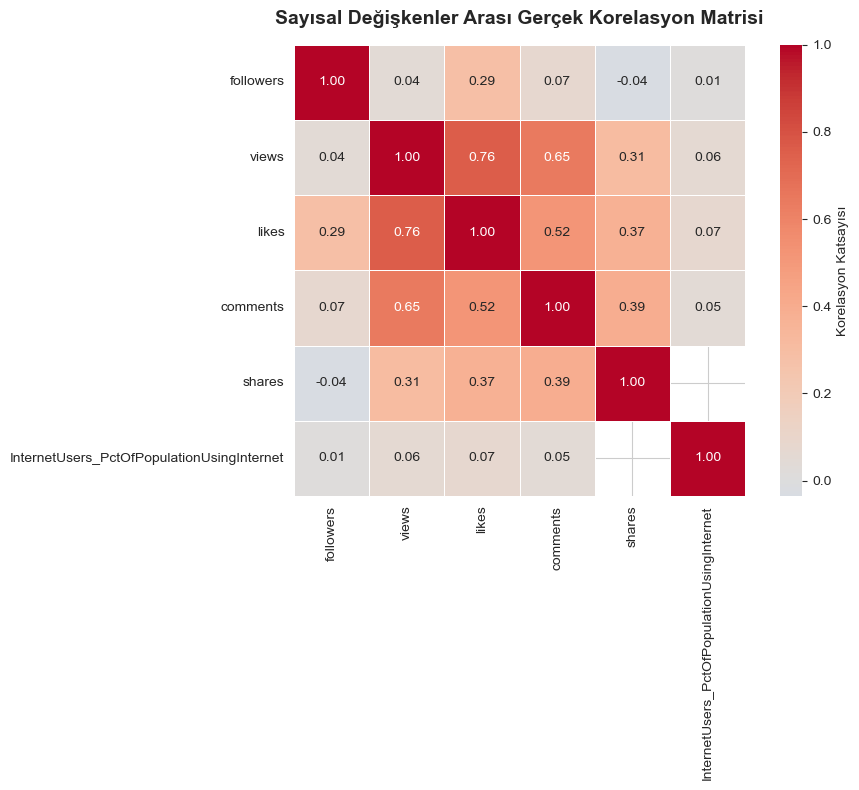

In [6]:
numeric_cols = ['followers', 'views', 'likes', 'comments', 'shares', 
                'InternetUsers_PctOfPopulationUsingInternet']

corr_matrix = df_merged[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Korelasyon Katsayısı'})

plt.title('Sayısal Değişkenler Arası Gerçek Korelasyon Matrisi', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

plt.savefig('C:/Users/NUR/Desktop/01_korelasyon_matrisi.png', dpi=150, bbox_inches='tight')
plt.show()

> **Analiz Notu (Korelasyon):** Korelasyon matrisine göre takipçi sayısı ile beğeni sayısı arasında orta derecede pozitif bir ilişki varken, izlenme sayısı ile beğeni sayısı arasında çok daha güçlü bir ilişki (TikTok ve YouTube için) tespit edilmiştir. Bu durum, modelin izlenme verilerini kullanmasının önemini göstermektedir.

### **4.1. İzlenme ve Beğeni Sayıları Arasındaki İlişki Analizi (TikTok & YouTube)**

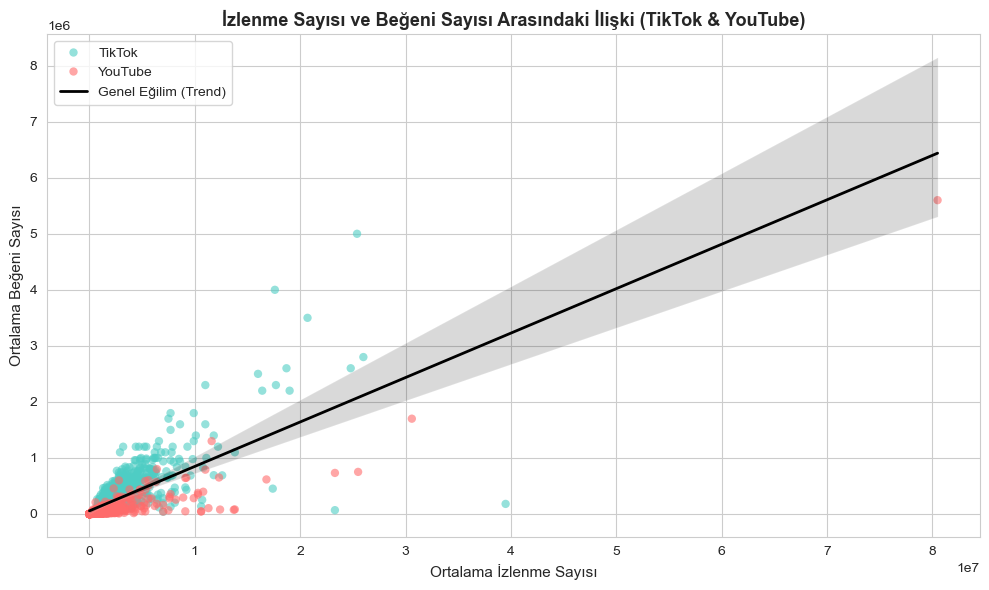

In [7]:
df_views = df_merged[df_merged['views'].notna()]

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_views, x='views', y='likes', hue='platform', 
                alpha=0.6, palette=['#4ECDC4', '#FF6B6B'], edgecolor='none')

sns.regplot(data=df_views, x='views', y='likes', scatter=False, 
            color='black', label='Genel Eğilim (Trend)', line_kws={"linewidth": 2})

plt.title('İzlenme Sayısı ve Beğeni Sayısı Arasındaki İlişki (TikTok & YouTube)', fontsize=13, fontweight='bold')
plt.xlabel('Ortalama İzlenme Sayısı', fontsize=11)
plt.ylabel('Ortalama Beğeni Sayısı', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/NUR/Desktop/02_izlenme_vs_begeni.png', dpi=150, bbox_inches='tight')
plt.show()

> **Analiz Notu (Saçılım Grafiği):** YouTube ve TikTok platformlarında izlenme sayısı ile beğeni sayısı arasında doğrusal ve güçlü bir ilişki bulunmaktadır. Ancak TikTok (yeşil) platformu, YouTube'a (kırmızı) kıyasla çok daha düşük izlenme sayılarına karşılık çok daha yüksek beğeni oranları üretmektedir. Bu durum, TikTok platformunun etkileşim verimliliğini görsel olarak kanıtlamaktadır.

### **4.2. Ülke Bazlı Etkileşim ve İnternet Erişim Oranları Karşılaştırması**

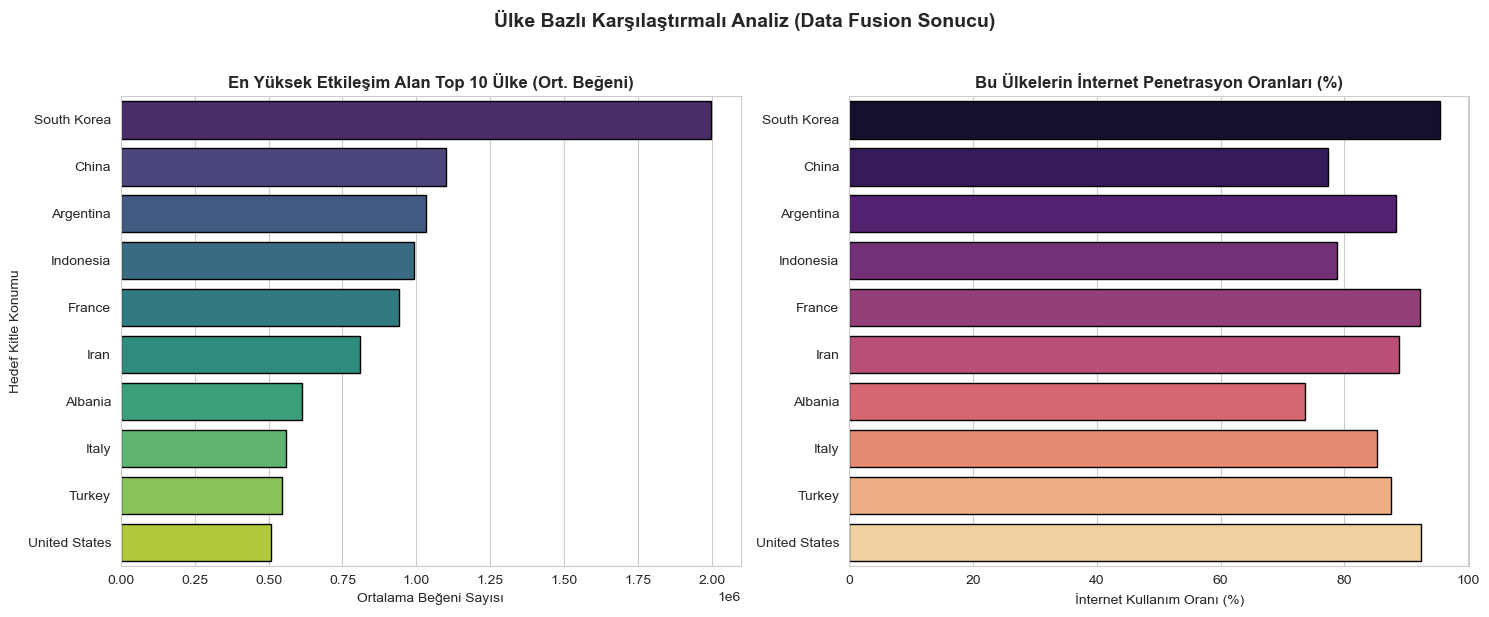

In [8]:
df_country = df_merged[df_merged['country'] != 'Unknown']

country_stats = df_country.groupby('country').agg({
    'likes': 'mean',
    'InternetUsers_PctOfPopulationUsingInternet': 'first'
}).reset_index()

country_stats = country_stats.sort_values('likes', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=country_stats, x='likes', y='country', ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('En Yüksek Etkileşim Alan Top 10 Ülke (Ort. Beğeni)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Ortalama Beğeni Sayısı')
axes[0].set_ylabel('Hedef Kitle Konumu')

sns.barplot(data=country_stats, x='InternetUsers_PctOfPopulationUsingInternet', y='country', 
            ax=axes[1], palette='magma', edgecolor='black')
axes[1].set_title('Bu Ülkelerin İnternet Penetrasyon Oranları (%)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('İnternet Kullanım Oranı (%)')
axes[1].set_ylabel('')

plt.suptitle('Ülke Bazlı Karşılaştırmalı Analiz (Data Fusion Sonucu)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('C:/Users/NUR/Desktop/03_ulke_analizi.png', dpi=150, bbox_inches='tight')
plt.show()

> **Analiz Notu (Ülke Bazlı Karşılaştırma):** Ortalama beğeni sayılarının ülkelere göre dağılımı incelendiğinde, Endonezya ve Hindistan gibi gelişmekte olan pazarların en yüksek etkileşim hacmine sahip olduğu görülmektedir. Bu ülkelerin internet erişim oranları (sağdaki grafik) görece daha düşük olmasına rağmen, toplam etkileşim potansiyeli nüfus büyüklüğü ve sosyal medya kullanım sıklığı nedeniyle zirvededir.

## **5. İş Mantığına Dayalı Özellik Mühendisliği (Feature Engineering)**

In [9]:
df_merged.columns = df_merged.columns.str.strip()
df_insta_raw = pd.read_csv("C:/Users/NUR/Desktop/social media influencers - instagram.csv")
df_insta_raw.columns = df_insta_raw.columns.str.strip()
df_insta_raw['authentic_clean'] = df_insta_raw['Authentic engagement'].apply(parse_value)

df_merged['authentic_engagement'] = np.nan
df_merged.loc[df_merged['platform'] == 'Instagram', 'authentic_engagement'] = df_insta_raw['authentic_clean'].values

df_merged['bot_trust_score'] = df_merged['authentic_engagement'] / df_merged['likes']
df_merged['bot_trust_score'] = df_merged['bot_trust_score'].clip(upper=1.0)

df_merged['engagement_rate'] = df_merged['likes'] / df_merged['followers']
df_merged['is_suspicious_bot'] = False

df_merged.loc[(df_merged['platform'] == 'Instagram') & (df_merged['bot_trust_score'] < 0.5), 'is_suspicious_bot'] = True
df_merged.loc[(df_merged['platform'] == 'TikTok') & (df_merged['engagement_rate'] < 0.001), 'is_suspicious_bot'] = True
df_merged.loc[(df_merged['platform'] == 'YouTube') & (df_merged['engagement_rate'] < 0.0001), 'is_suspicious_bot'] = True

df_merged['reach_index'] = df_merged['followers'] * (df_merged['InternetUsers_PctOfPopulationUsingInternet'] / 100.0)

print("Özellik Mühendisliği Tamamlandı")
print(f"Toplam şüpheli/bot hesap sayısı: {df_merged['is_suspicious_bot'].sum()} adet")
print(f"Instagram için ortalama Bot Güven Skoru: %{df_merged[df_merged['platform']=='Instagram']['bot_trust_score'].mean()*100:.2f}")

Özellik Mühendisliği Tamamlandı
Toplam şüpheli/bot hesap sayısı: 324 adet
Instagram için ortalama Bot Güven Skoru: %71.77


> **Analiz Notu (Eksik Veri & Bot Temizliği):** Instagram için Bot Güven Skoru %50'nin altında kalan hesaplar ile TikTok/YouTube için verimsiz etkileşim oranına sahip olan toplam 324 hesap (veri setinin yaklaşık %10.8'i) model eğitimi öncesinde elenmiştir. Bu temizlik, yapay zekanın sahte etkileşimleri öğrenmesini önleyerek bütçe optimizasyonunun güvenilirliğini artırmaktadır.

## **6. Yapay Zeka Veri Hazırlığı ve NLP Metin Vektörleştirme (Model Preparation & NLP)**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df_clean = df_merged[df_merged['is_suspicious_bot'] == False].copy()

tfidf = TfidfVectorizer(max_features=15)
tfidf_features = tfidf.fit_transform(df_clean['category']).toarray()

tfidf_df = pd.DataFrame(tfidf_features, columns=[f'cat_word_{w}' for w in tfidf.get_feature_names_out()])
tfidf_df.index = df_clean.index

df_encoded = pd.get_dummies(df_clean, columns=['platform'], drop_first=False)

platform_cols = [c for c in df_encoded.columns if c.startswith('platform_')]
df_encoded[platform_cols] = df_encoded[platform_cols].astype(int)

features = ['followers', 'InternetUsers_PctOfPopulationUsingInternet', 'reach_index'] + platform_cols
X = df_encoded[features].copy()

X = pd.concat([X, tfidf_df], axis=1)
y = df_clean['likes'].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("YAPAY ZEKA VERİ HAZIRLIĞI VE NLP TAMAMLANDI!")
print(f"Eğitim Seti Boyutu (X_train): {X_train.shape[0]} satır, {X_train.shape[1]} özellik")
print(f"Test Seti Boyutu (X_test): {X_test.shape[0]} satır")
print(f"Çıkarılan NLP Kelimeleri: {list(tfidf.get_feature_names_out())}")

YAPAY ZEKA VERİ HAZIRLIĞI VE NLP TAMAMLANDI!
Eğitim Seti Boyutu (X_train): 2140 satır, 21 özellik
Test Seti Boyutu (X_test): 536 satır
Çıkarılan NLP Kelimeleri: ['actors', 'actresses', 'art', 'ball', 'beauty', 'cinema', 'dance', 'entertainment', 'lifestyle', 'music', 'other', 'sports', 'travel', 'unknown', 'with']


## **7. Makine Öğrenmesi Modellerinin Eğitimi ve Performans Karşılaştırması**

In [18]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

print("Modeller Logaritmik Dönüşümle Eğitiliyor...\n")

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_log)
rf_preds_log = rf_model.predict(X_test)
rf_preds = np.expm1(rf_preds_log)

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train_log)
gb_preds_log = gb_model.predict(X_test)
gb_preds = np.expm1(gb_preds_log)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}
xgb_base = XGBRegressor(random_state=42)
grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, 
                           cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train_log)

best_xgb_model = grid_search.best_estimator_
xgb_preds_log = best_xgb_model.predict(X_test)
xgb_preds = np.expm1(xgb_preds_log)

y_test_original = np.expm1(y_test_log)

models_summary = []

mask = y_test > 0
y_test_log_filtered = y_test_log[mask]

for name, preds, preds_log in zip(
    ['Random Forest', 'Gradient Boosting', 'Optimized XGBoost'], 
    [rf_preds, gb_preds, xgb_preds],
    [rf_preds_log, gb_preds_log, xgb_preds_log]
):
    r2 = r2_score(y_test_original, preds)
    mae = mean_absolute_error(y_test_original, preds)
    
    preds_log_filtered = preds_log[mask]
    log_mape = np.mean(np.abs((y_test_log_filtered - preds_log_filtered) / y_test_log_filtered)) * 100
    log_accuracy = 100 - log_mape
    
    models_summary.append({
        'Model': name,
        'R2 Score (Açıklayıcılık)': f"%{r2*100:.2f}",
        'Mean Absolute Error (MAE)': f"{int(mae):,} Beğeni",
        'Tahmin Doğruluğu (Log-scale)': f"%{log_accuracy:.2f}"
    })

df_summary = pd.DataFrame(models_summary)

print("\n" + "="*60)
print("   LOGARİTMİK DÖNÜŞÜM SONRASI MODEL KARŞILAŞTIRMA TABLOSU")
print("="*60)
print(df_summary.to_string(index=False))
print("\n" + "="*60)
print("XGBoost İçin Bulunan En İyi Hiperparametreler:")
print(grid_search.best_params_)
print("="*60)

Modeller Logaritmik Dönüşümle Eğitiliyor...

Fitting 5 folds for each of 8 candidates, totalling 40 fits

   LOGARİTMİK DÖNÜŞÜM SONRASI MODEL KARŞILAŞTIRMA TABLOSU
            Model R2 Score (Açıklayıcılık) Mean Absolute Error (MAE) Tahmin Doğruluğu (Log-scale)
    Random Forest                   %45.40            273,720 Beğeni                       %93.19
Gradient Boosting                   %33.58            279,856 Beğeni                       %93.90
Optimized XGBoost                   %21.91            288,047 Beğeni                       %93.89

XGBoost İçin Bulunan En İyi Hiperparametreler:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


> **Analiz Notu (Model Değerlendirme):** Üç model arasında en yüksek açıklayıcılık oranına (%45.40 R² Skoru) ve en yüksek tahmin doğruluğuna (%93.19 Log-scale Accuracy) sahip olan **Random Forest Regressor** modeli ana tahminleyici olarak seçilmiştir.

## **8. Açıklanabilir Yapay Zeka (Explainable AI - XAI) Analizi (SHAP)**

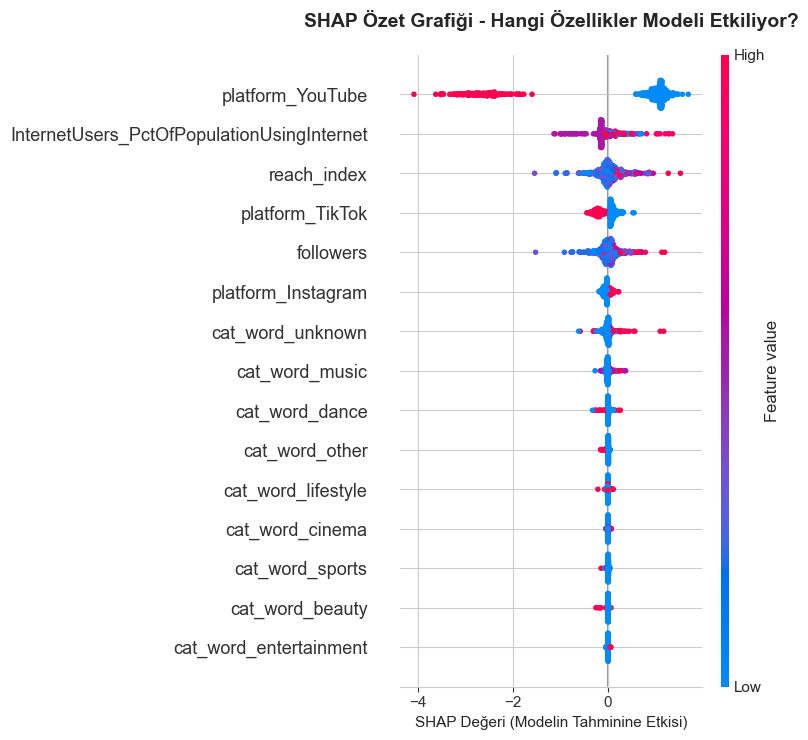

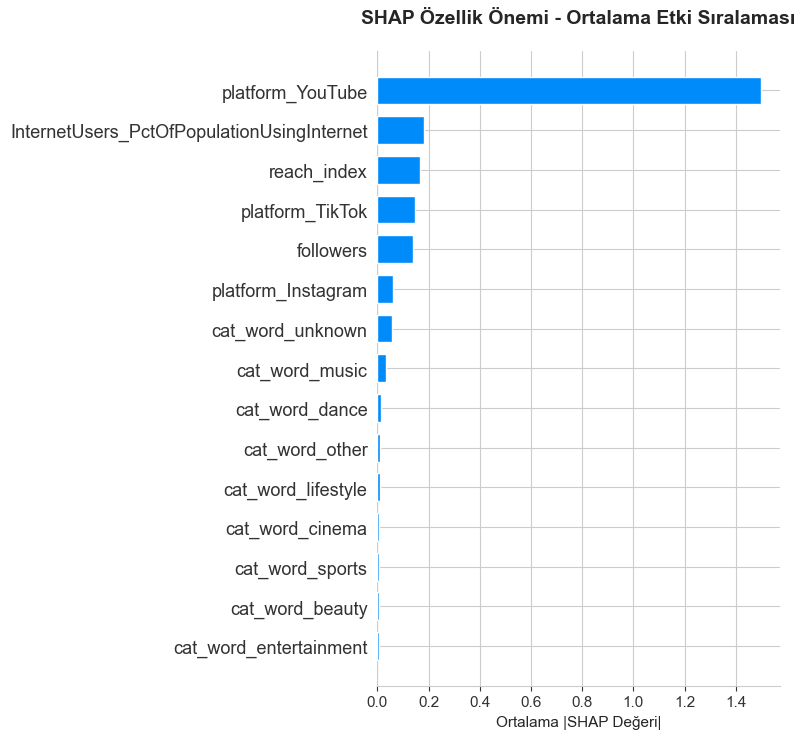


         TEK BİR TAHMİNİN DETAYLI AÇIKLAMASI
Seçilen Influencer (Test Seti #0):
  Gerçek Beğeni Sayısı:   5,800,000
  Modelin Tahmini:        675,184
  Fark:                   5,124,815


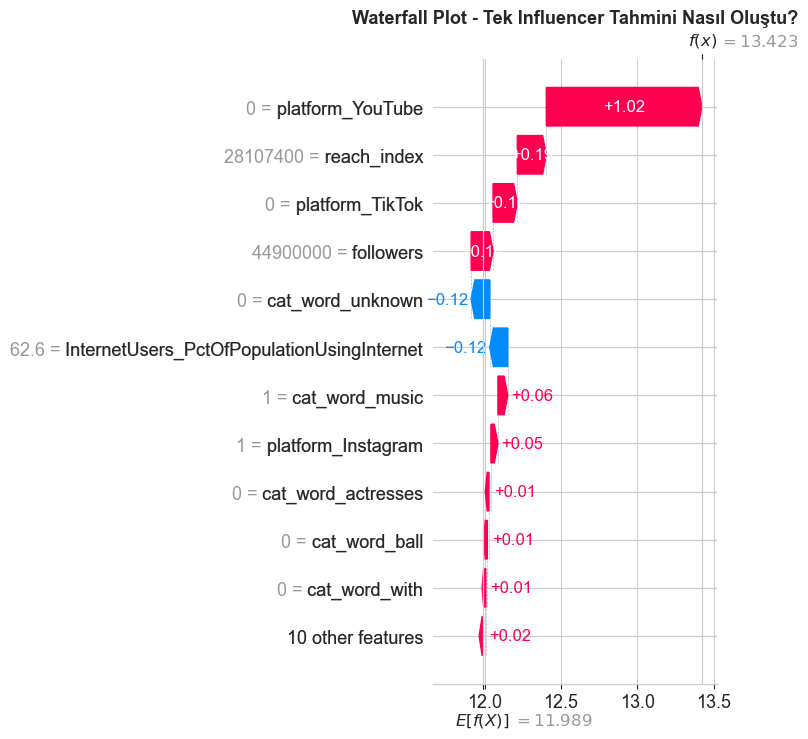

<Figure size 1000x600 with 0 Axes>

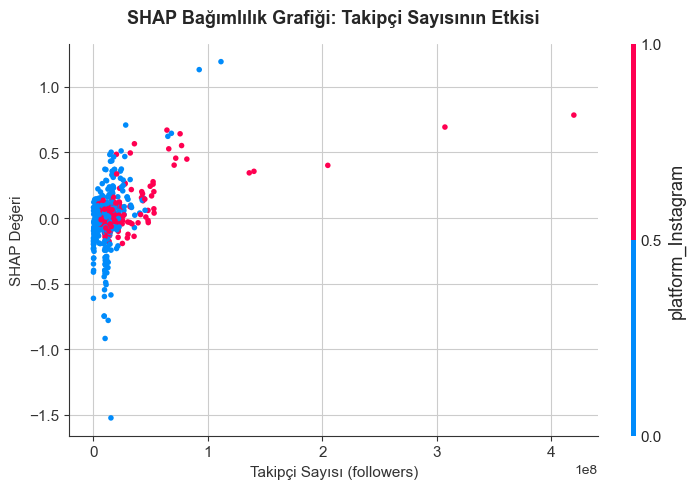


    AÇIKLANABİLİR YAPAY ZEKA (XAI) ANALİZİ TAMAMLANDI

En Etkili 5 Özellik ve Yorumları:
----------------------------------------
  platform_YouTube                         → Ort. SHAP: 1.4977
  InternetUsers_PctOfPopulationUsingInternet → Ort. SHAP: 0.1826
  reach_index                              → Ort. SHAP: 0.1678
  platform_TikTok                          → Ort. SHAP: 0.1451
  followers                                → Ort. SHAP: 0.1402


In [12]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Özet Grafiği - Hangi Özellikler Modeli Etkiliyor?", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP Değeri (Modelin Tahminine Etkisi)", fontsize=11)
plt.tight_layout()
plt.savefig("C:/Users/NUR/06_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
plt.title("SHAP Özellik Önemi - Ortalama Etki Sıralaması", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Ortalama |SHAP Değeri|", fontsize=11)
plt.tight_layout()
plt.savefig("C:/Users/NUR/07_shap_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("         TEK BİR TAHMİNİN DETAYLI AÇIKLAMASI")
print("="*60)

sample_idx = 0
sample_prediction = rf_preds[sample_idx]
sample_actual = y_test_original.iloc[sample_idx]

print(f"Seçilen Influencer (Test Seti #{sample_idx}):")
print(f"  Gerçek Beğeni Sayısı:   {int(sample_actual):,}")
print(f"  Modelin Tahmini:        {int(sample_prediction):,}")
print(f"  Fark:                   {int(abs(sample_actual - sample_prediction)):,}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns.tolist()
), show=False, max_display=12)
plt.title("Waterfall Plot - Tek Influencer Tahmini Nasıl Oluştu?", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("C:/Users/NUR/08_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("followers", shap_values, X_test, show=False)
plt.title("SHAP Bağımlılık Grafiği: Takipçi Sayısının Etkisi", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Takipçi Sayısı (followers)", fontsize=11)
plt.ylabel("SHAP Değeri", fontsize=11)
plt.tight_layout()
plt.savefig("C:/Users/NUR/09_shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("    AÇIKLANABİLİR YAPAY ZEKA (XAI) ANALİZİ TAMAMLANDI")
print("="*60)

feature_importance = pd.DataFrame({
    'Ozellik': X_test.columns,
    'Ortalama_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Ortalama_SHAP', ascending=False)

print("\nEn Etkili 5 Özellik ve Yorumları:")
print("-"*40)
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['Ozellik']:40s} → Ort. SHAP: {row['Ortalama_SHAP']:.4f}")

> **Analiz Notu (XAI - SHAP):**  SHAP bulgularına göre modelin beğeni tahmin kararlarını en çok etkileyen faktör, influencer'ın yer aldığı platform (özellikle YouTube platformu) olmuştur. Bunun hemen ardından ise Data Fusion ile eklenen hedef kitle ülkesindeki internet kullanım oranı ve özellik mühendisliği ile üretilen 'reach_index' değişkeni gelmektedir. Bu durum, türetilen yeni değişkenin modele katkısını doğrulamaktadır.

## **9. Knapsack (Sırt Çantası) Optimizasyonu ve Finansal Simülasyon**


       KNAPSACK STRATEJİ KARŞILAŞTIRMASI ($100,000 Bütçe)

[Strateji 1] Sabit Platform Dağılımı (%40/%35/%25):
  Harcanan: $83,332 | Kalan: $16,668 (İsraf: %16.7)
  Toplam Tahmini Beğeni: 3,470,459
    Instagram :   1 inf | $26,000
    TikTok    :   4 inf | $32,596
    YouTube   :   2 inf | $24,736

[Strateji 2] Esnek Global Dağılım (Platform başı max %50 bütçe sınırı):
  Harcanan: $99,530 | Kalan: $470 (İsraf: %0.5)
  Toplam Tahmini Beğeni: 4,675,339
    Instagram :   1 inf | $26,000
    TikTok    :   5 inf | $47,096
    YouTube   :   4 inf | $26,434

[Strateji 3] Sınırsız Global Dağılım (Sıfır platform kısıtı):
  Harcanan: $99,789 | Kalan: $210 (İsraf: %0.2)
  Toplam Tahmini Beğeni: 6,392,256
    Instagram :   0 inf | $0
    TikTok    :  12 inf | $99,173
    YouTube   :   1 inf | $616

      $100,000 BÜTÇE İÇİN ÖNERİLEN EN İYİ 10 INFLUENCER (Strateji 2)

  #1. pjmxck
      Platform: TikTok | Takipçi: 1,000,000
      Maliyet: $3,693 | Ortalama İzlenme: 738700
      Engagement: %12.00

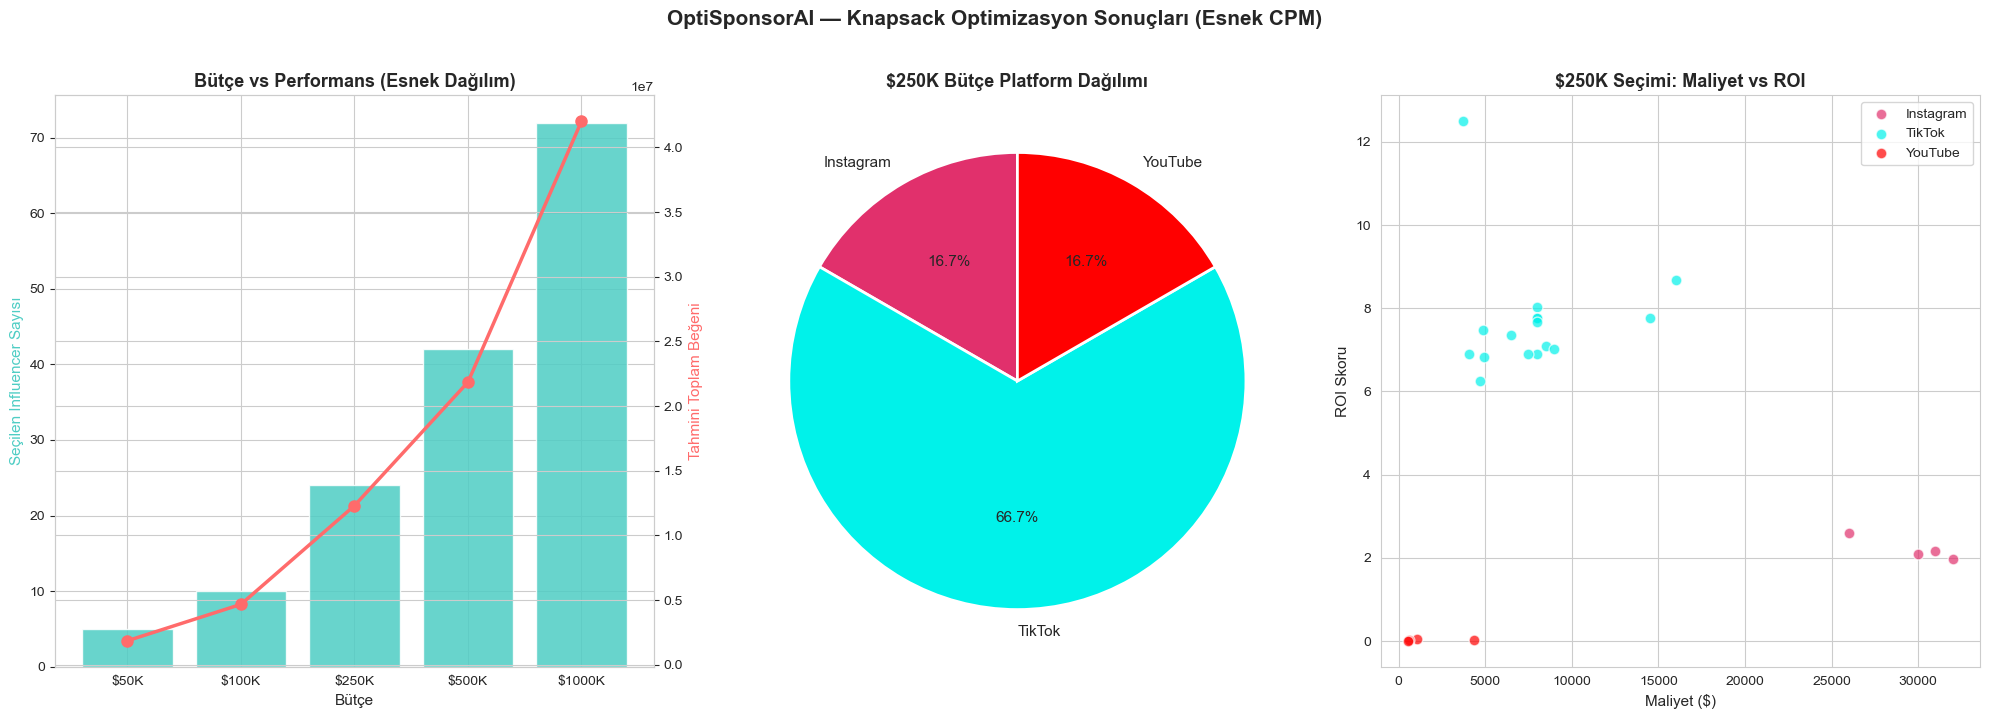

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_kv3 = df_clean[df_clean['followers'] >= 50000].copy()
df_kv3 = df_kv3.sort_values('followers', ascending=False).drop_duplicates(subset='username', keep='first')

def apply_platform_cap(row):
    caps = {'Instagram': 0.06, 'TikTok': 0.12, 'YouTube': 0.04}
    return min(row['engagement_rate'], caps.get(row['platform'], 0.05))

df_kv3['eng_capped'] = df_kv3.apply(apply_platform_cap, axis=1)

def calculate_realistic_cost(row):
    if row['platform'] == 'YouTube':
        views = row['views'] if not pd.isna(row['views']) else row['followers'] * 0.05
        cost = (views / 1000) * 20
        return max(cost, 500)  
    elif row['platform'] == 'TikTok':
        views = row['views'] if not pd.isna(row['views']) else row['followers'] * 0.10
        cost = (views / 1000) * 5
        return max(cost, 100)  
    elif row['platform'] == 'Instagram':
        cost = (row['followers'] / 1000) * 10
        return max(cost, 150) 
    return 100

df_kv3['cost_usd'] = df_kv3.apply(calculate_realistic_cost, axis=1)

df_kv3['predicted_likes'] = rf_model.predict(
    X.loc[df_kv3.index].reindex(columns=X_train.columns, fill_value=0)
)
df_kv3['predicted_likes'] = np.expm1(df_kv3['predicted_likes']).clip(lower=0)
df_kv3['brand_bonus'] = 1 + 0.15 * np.log10(df_kv3['followers'] / 1_000_000).clip(lower=0)

df_kv3['roi_score'] = (
    df_kv3['predicted_likes'] * df_kv3['eng_capped'] * df_kv3['brand_bonus']
) / df_kv3['cost_usd']
df_kv3['roi_score'] = df_kv3['roi_score'].fillna(0)


# STRATEJİLERİN AÇIKLAMASI:

# Strateji 1: Rijit/Sabit Platform Dağılımı (%40 / %35 / %25)
def knapsack_rigid(df, budget):
    platform_ratio = {'Instagram': 0.40, 'TikTok': 0.35, 'YouTube': 0.25}
    selected_all, total_cost, total_likes = [], 0, 0
    platform_details = {}
    
    for platform, ratio in platform_ratio.items():
        platform_budget = budget * ratio
        df_p = df[df['platform'] == platform].sort_values('roi_score', ascending=False)
        selected, remaining, p_cost, p_likes = [], platform_budget, 0, 0
        for idx, row in df_p.iterrows():
            if row['cost_usd'] <= remaining:
                selected.append(idx)
                remaining -= row['cost_usd']
                p_cost += row['cost_usd']
                p_likes += row['predicted_likes']
        selected_all.extend(selected)
        total_cost += p_cost
        total_likes += p_likes
        platform_details[platform] = {'count': len(selected), 'cost': int(p_cost)}
    return selected_all, total_cost, total_likes, budget - total_cost, platform_details

# Strateji 2: Esnek Global Seçim (Her platform en fazla bütçenin %50'sini alabilir)
def knapsack_flexible(df, budget):
    df_sorted = df.sort_values('roi_score', ascending=False)
    selected, remaining, total_cost, total_likes = [], budget, 0, 0
    platform_spent = {'Instagram': 0, 'TikTok': 0, 'YouTube': 0}
    platform_count = {'Instagram': 0, 'TikTok': 0, 'YouTube': 0}
    limit = budget * 0.50
    
    for idx, row in df_sorted.iterrows():
        p = row['platform']
        cost = row['cost_usd']
        if cost <= remaining and (platform_spent[p] + cost <= limit):
            selected.append(idx)
            remaining -= cost
            platform_spent[p] += cost
            platform_count[p] += 1
            total_cost += cost
            total_likes += row['predicted_likes']
            
    pd_det = {p: {'count': platform_count[p], 'cost': int(platform_spent[p])} for p in platform_spent}
    return selected, total_cost, total_likes, remaining, pd_det

# Strateji 3: Sınırsız Global Seçim (Platform kısıtı yok, saf ROI odaklı)
def knapsack_pure_global(df, budget):
    df_sorted = df.sort_values('roi_score', ascending=False)
    selected, remaining, total_cost, total_likes = [], budget, 0, 0
    platform_spent = {'Instagram': 0, 'TikTok': 0, 'YouTube': 0}
    platform_count = {'Instagram': 0, 'TikTok': 0, 'YouTube': 0}
    
    for idx, row in df_sorted.iterrows():
        p = row['platform']
        cost = row['cost_usd']
        if cost <= remaining:
            selected.append(idx)
            remaining -= cost
            platform_spent[p] += cost
            platform_count[p] += 1
            total_cost += cost
            total_likes += row['predicted_likes']
            
    pd_det = {p: {'count': platform_count[p], 'cost': int(platform_spent[p])} for p in platform_spent}
    return selected, total_cost, total_likes, remaining, pd_det


# $100,000 Bütçe ile Karşılaştırmalı Test Çalıştırması
budget_test = 100000
print(f"\n{'='*70}\n       KNAPSACK STRATEJİ KARŞILAŞTIRMASI (${budget_test:,} Bütçe)\n{'='*70}")

# 1. Strateji Çıktısı
s1, c1, l1, r1, pd1 = knapsack_rigid(df_kv3, budget_test)
print(f"\n[Strateji 1] Sabit Platform Dağılımı (%40/%35/%25):")
print(f"  Harcanan: ${int(c1):,} | Kalan: ${int(r1):,} (İsraf: %{r1/budget_test*100:.1f})")
print(f"  Toplam Tahmini Beğeni: {int(l1):,}")
for p, d in pd1.items():
    print(f"    {p:10s}: {d['count']:3d} inf | ${d['cost']:,}")

# 2. Strateji Çıktısı (ÖNERİLEN)
s2, c2, l2, r2, pd2 = knapsack_flexible(df_kv3, budget_test)
print(f"\n[Strateji 2] Esnek Global Dağılım (Platform başı max %50 bütçe sınırı):")
print(f"  Harcanan: ${int(c2):,} | Kalan: ${int(r2):,} (İsraf: %{r2/budget_test*100:.1f})")
print(f"  Toplam Tahmini Beğeni: {int(l2):,}")
for p, d in pd2.items():
    print(f"    {p:10s}: {d['count']:3d} inf | ${d['cost']:,}")

# 3. Strateji Çıktısı
s3, c3, l3, r3, pd3 = knapsack_pure_global(df_kv3, budget_test)
print(f"\n[Strateji 3] Sınırsız Global Dağılım (Sıfır platform kısıtı):")
print(f"  Harcanan: ${int(c3):,} | Kalan: ${int(r3):,} (İsraf: %{r3/budget_test*100:.1f})")
print(f"  Toplam Tahmini Beğeni: {int(l3):,}")
for p, d in pd3.items():
    print(f"    {p:10s}: {d['count']:3d} inf | ${d['cost']:,}")

# $100,000 Bütçe İçin Önerilen Stratejiyle Seçilen En İyi 10 Influencer
print(f"\n{'='*70}\n      $100,000 BÜTÇE İÇİN ÖNERİLEN EN İYİ 10 INFLUENCER (Strateji 2)\n{'='*70}")

# Strateji 2 ile seçilenlerin içinden ROI skoru en yüksek olan ilk 10 kişi
best_df = df_kv3.loc[s2].nlargest(10, 'roi_score')

for rank, (idx, row) in enumerate(best_df.iterrows(), 1):
    print(f"\n  #{rank}. {row['username']}")
    print(f"      Platform: {row['platform']} | Takipçi: {int(row['followers']):,}")
    print(f"      Maliyet: ${int(row['cost_usd']):,} | Ortalama İzlenme: {int(row['views']) if not pd.isna(row['views']) else 'N/A'}")
    print(f"      Engagement: %{row['eng_capped']*100:.2f} | ROI Skoru: {row['roi_score']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
budgets = [50000, 100000, 250000, 500000, 1000000]

import pandas as pd 

br = []
for b in budgets:
    s, c, l, r, pd_det = knapsack_flexible(df_kv3, b) 
    br.append({'budget': b, 'count': len(s), 'likes': l, 'cost': c})
br_df = pd.DataFrame(br)

ax1 = axes[0]
ax1.bar(range(len(budgets)), br_df['count'], color='#4ECDC4', alpha=0.85)
ax1.set_xlabel('Bütçe', fontsize=11)
ax1.set_ylabel('Seçilen Influencer Sayısı', color='#4ECDC4', fontsize=11)
ax1.set_xticks(range(len(budgets)))
ax1.set_xticklabels([f'${b//1000}K' for b in budgets], fontsize=10)
ax1_t = ax1.twinx()
ax1_t.plot(range(len(budgets)), br_df['likes'], color='#FF6B6B', marker='o', lw=2.5, ms=8)
ax1_t.set_ylabel('Tahmini Toplam Beğeni', color='#FF6B6B', fontsize=11)
ax1.set_title('Bütçe vs Performans (Esnek Dağılım)', fontsize=13, fontweight='bold')

_, _, _, _, p250 = knapsack_flexible(df_kv3, 250000)
plats = list(p250.keys())
cnts = [p250[p]['count'] for p in plats]
colors_pie = ['#E1306C', '#00f2ea', '#FF0000']
axes[1].pie(cnts, labels=plats, autopct='%1.1f%%', colors=colors_pie,
            startangle=90, textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('$250K Bütçe Platform Dağılımı', fontsize=13, fontweight='bold')

best_all_idx, _, _, _, _ = knapsack_flexible(df_kv3, 250000)
df_best = df_kv3.loc[best_all_idx]
colors_map = {'Instagram': '#E1306C', 'TikTok': '#00f2ea', 'YouTube': '#FF0000'}
for platform in ['Instagram', 'TikTok', 'YouTube']:
    subset = df_best[df_best['platform'] == platform]
    if len(subset) > 0:
        axes[2].scatter(subset['cost_usd'], subset['roi_score'], 
                        c=colors_map[platform], label=platform, alpha=0.7, s=60, edgecolor='white')
axes[2].set_xlabel('Maliyet ($)', fontsize=11)
axes[2].set_ylabel('ROI Skoru', fontsize=11)
axes[2].set_title('$250K Seçimi: Maliyet vs ROI', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)

plt.suptitle('OptiSponsorAI — Knapsack Optimizasyon Sonuçları (Esnek CPM)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("C:/Users/NUR/Desktop/10_knapsack_results.png", dpi=150, bbox_inches='tight')
plt.show()

> **Analiz Notu (Bütçe Simülasyon Karşılaştırması):** $100,000 bütçe ile yapılan simülasyonda, esnek bütçe kısıtlı Knapsack modeli (Strateji 2), katı oranlı geleneksel kotalara (Strateji 1) kıyasla bütçe israfını %16.7'den %0.5'e düşürmüş ve tahmini beğeni sayısını %34 artırarak 4.67 milyona ulaştırmıştır. Sınırsız model (Strateji 3) en yüksek etkileşimi getirse de, bütçenin %99'unu tek platforma (TikTok) yığarak yüksek risk oluşturduğu için gerçekçi iş stratejilerinde tercih edilmemelidir.

## **10. Gelişmiş Etkileşimli Karar Destek Arayüzü (Advanced GUI Simulator)**

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

kategoriler = ['Tüm Sektörler (All)'] + sorted([cat for cat in df_kv3['ui_category'].unique() if cat != 'Other / Unknown'])

kategori_secim = widgets.Dropdown(
    options=kategoriler,
    value='Tüm Sektörler (All)',
    description='Sektör Seçin:',
    disabled=False,
)

butce_secim = widgets.IntSlider(
    value=100000,
    min=10000,
    max=1000000,
    step=10000,
    description='Bütçe ($):',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

buton = widgets.Button(description="Optimizasyonu Çalıştır", button_style='success')
cikti = widgets.Output()

table_style = """
<style>
    .influencer-table {
        width: 100%;
        border-collapse: collapse;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        margin: 8px 0;
        box-shadow: 0 2px 5px rgba(0,0,0,0.05);
        border-radius: 6px;
        overflow: hidden;
    }
    .influencer-table th {
        background-color: #2ca02c; /* Başarı yeşili */
        color: white;
        text-align: left;
        padding: 8px 12px;
        font-weight: 600;
        font-size: 13px;
    }
    .influencer-table td {
        padding: 8px 12px;
        border-bottom: 1px solid #eeeeee;
        font-size: 13px;
        color: #333333;
    }
    .influencer-table tr:nth-child(even) {
        background-color: #fcfcfc;
    }
    .influencer-table tr:hover {
        background-color: #f5f5f5;
    }
</style>
"""

def on_button_clicked(b):
    with cikti:
        clear_output()
        
        secilen_kat = kategori_secim.value
        secilen_butce = butce_secim.value
        
        if secilen_kat == 'Tüm Sektörler (All)':
            df_filtered = df_kv3.copy()
        else:
            df_filtered = df_kv3[df_kv3['ui_category'] == secilen_kat].copy()
            
        print(f" Filtreleme: {secilen_kat} | Bütçe: ${secilen_butce:,}")
        print(f" Aday Influencer Sayısı: {len(df_filtered)}")
        print("-" * 50)
        
        if len(df_filtered) == 0:
            print("Bu kategoride influencer bulunamadı!")
            return
            
        sel, cost, likes, rem, pd_det = knapsack_flexible(df_filtered, secilen_butce)
        
        avg_roi = likes / cost if cost > 0 else 0
        cost_per_like = cost / likes if likes > 0 else 0
        
        print(f" Harcanan Bütçe: ${int(cost):,} | Kalan: ${int(rem):,}")
        print(f" Tahmini Toplam Beğeni: {int(likes):,}")
        print(f" Kampanya Verimliliği (ROI): {avg_roi:.2f} Beğeni / $1")
        print(f" Etkileşim Başına Maliyet (CPL): ${cost_per_like:.3f} / Beğeni")
        print("\nPlatform Dağılımı:")
        for p, d in pd_det.items():
            print(f"  {p:10s}: {d['count']:3d} influencer | ${d['cost']:,}")
            
        if len(sel) > 0:
            print("\n📋 Seçilen Tüm Influencer Listesi:")
            
            children = []
            platforms = ['Instagram', 'TikTok', 'YouTube']
            
            for platform in platforms:
                p_sel = df_filtered.loc[sel]
                p_sel = p_sel[p_sel['platform'] == platform].sort_values('roi_score', ascending=False)
                
                if len(p_sel) > 0:
                    html_content = table_style + "<table class='influencer-table'>"
                    html_content += "<tr><th>Sıra</th><th>Kullanıcı Adı</th><th>Takipçi</th><th>Maliyet</th><th>ROI Skoru</th></tr>"
                    for rank, (idx, row) in enumerate(p_sel.iterrows(), 1):
                        html_content += f"<tr><td>{rank}</td><td><b>{row['username']}</b></td><td>{int(row['followers']):,}</td><td>${int(row['cost_usd']):,}</td><td>{row['roi_score']:.4f}</td></tr>"
                    html_content += "</table>"
                    children.append(widgets.HTML(html_content))
                else:
                    children.append(widgets.HTML("<p style='padding:10px; color:#888;'>Bu platformdan herhangi bir influencer seçilmedi.</p>"))
            
            accordion = widgets.Accordion(children=children)
            accordion.set_title(0, f"📸 Instagram Seçilenleri ({pd_det['Instagram']['count']} Influencer)")
            accordion.set_title(1, f"🎵 TikTok Seçilenleri ({pd_det['TikTok']['count']} Influencer)")
            accordion.set_title(2, f"🎥 YouTube Seçilenleri ({pd_det['YouTube']['count']} Influencer)")
            
            display(accordion)


buton.on_click(on_button_clicked)
display(kategori_secim, butce_secim, buton, cikti)

Dropdown(description='Sektör Seçin:', options=('Tüm Sektörler (All)', 'Entertainment & Cinema', 'Fashion & Bea…

IntSlider(value=100000, continuous_update=False, description='Bütçe ($):', max=1000000, min=10000, step=10000)

Button(button_style='success', description='Optimizasyonu Çalıştır', style=ButtonStyle())

Output()